In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import json
# import DigitalMicrograph as DM
import ctypes  # An included library with Python install. 

def hspy_file_light(file_name):
   hspy_file = h5py.File(file_name, 'r')
   root_name = hspy_file['Experiments']
   sets = list(root_name.keys())
   for s in range(len(sets)):
      data=np.copy(np.transpose(root_name[sets[s]]['data']),order = 'C') 
      key_list = list(root_name[sets[s]].keys())
      data_type=root_name[sets[s]]['metadata']['Signal'].attrs['signal_type']
      detectors=list(root_name[sets[s]]['metadata']['Acquisition_instrument']['TEM']['Detector'].keys())
      print(detectors)
      is_eels=False
      if data_type=='EELS':
         is_eels=True
      axes_name=[]
      axes_offset=[]
      axes_scale=[]
      axis=0
      for i in range(len(key_list)):
         if (key_list[i][0:4] == 'axis'):
            name = root_name[sets[s]][key_list[i]].attrs['name']
            offset = root_name[sets[s]][key_list[i]].attrs['offset']
            scale = root_name[sets[s]][key_list[i]].attrs['scale']
            axes_name.append(name)
            axes_offset.append(offset)
            axes_scale.append(scale)
            axis+=1
      show_data(data, sets[s], axes_name, axes_offset, axes_scale, is_eels)
def open_emd(fname):
    ## Open the emd file to read
    fname=fname
    emdFile = h5py.File(fname,'r')
    # Check for STEM images:
    try:
        image_keys=list(emdFile['Data']['Image'].keys())
    except:
        print("No scan images")
        image_keys=[]
   
###next 4 lines are commented out to accomodate multiframe data organization, if singleframe you can uncomment
# for image_key in image_keys:
    #    metadata_array=np.array(emdFile['Data']['Image'][image_key]['Metadata'])
     #   metadata_char = md_char = ''.join([chr(i[0]) for i in metadata_array if i != 0])
      #  metadata_json = json.loads(metadata_char)
    # Check if the file contains EELS Feature
    grp_features = emdFile['Features']
    features = list(grp_features.keys())
    if 'SIFeature' in features:
        has_SI=True
    else:
        has_SI=False
    if has_SI:
        try:
            groupCubes = emdFile['Data/EelsSpectrumImage']
        except:
            msg=r"No 'Data/EelsSpectrumImage' present in this file"
            ctypes.windll.user32.MessageBoxW(0, msg, "No EELS SI", 1)
            exit()
        si_cubes_data=[]
        si_cubes_metadata=[]
        cube_names=[]
        # List of cubes
        si_cubes= list(groupCubes.keys())
        for cube_name in list(groupCubes.keys()):
            cube = groupCubes[cube_name]
            cube_names.append(cube_name)
            cube_shape=cube['Data'].shape
            print("Cube: "+str(cube_name)+", shape:"+str(cube_shape))
            cube_data = np.empty(cube_shape, dtype=np.float32)
            for chunk in cube['Data'].iter_chunks():
                cube_data[chunk] = cube['Data'][chunk]
            si_cubes_data.append(np.copy(cube_data)-100)
            metadata={}
            metadata_array = np.array(cube['Metadata'])
            metadata_char = md_char = ''.join([chr(i[0]) for i in metadata_array if i != 0])
            metadata_json = json.loads(metadata_char)
            try:
                acqusitionMetadata_array = np.array(cube['AcquisitionMetadata'])
            except:
                msg=r"This .emd file has no 'AcquisitionMetadata'. This script doesn't support this file format"
                ctypes.windll.user32.MessageBoxW(0, msg, "Failed to find AcquisitionMetadata", 1)
                exit()
            a =  acqusitionMetadata_array[:, [0]]
            a.reshape(a.shape[0])
            acqusitionMetadata =  ''.join([chr(i[0]) for i in a if i != 0])
            acqusitionMetadata_json = json.loads(acqusitionMetadata)
            for key in list(acqusitionMetadata_json['Data'].keys()):
                metadata[key]=acqusitionMetadata_json['Data'][key]
            metadata['raw_object']=metadata_json
            collection_angle_begin = float(metadata_json["CustomProperties"]["EnergyFilter.CollectionAngleRange.Begin"]["value"])
            collection_angle_end = float(metadata_json["CustomProperties"]["EnergyFilter.CollectionAngleRange.End"]["value"])
            metadata["collection_angle_begin"]=collection_angle_begin
            metadata["collection_angle_end"]=collection_angle_end
            beam_voltage = int(metadata_json["Optics"]["AccelerationVoltage"])
            metadata["beam_voltage"]=beam_voltage
            si_cubes_metadata.append(metadata)
        emdFile.close()
        print(si_cubes_data[0][0:10,0,0])
        for i in range(len(si_cubes_data)):
            shape_before=str(si_cubes_data[i].shape)
            reshaped=np.transpose(np.array(si_cubes_data[i]),axes=(0,2,1)) #reshape
            #reshaped=np.swapaxes(si_cubes_data[i],1,0)
            print("Cube reshaped from "+shape_before+" to "+str(reshaped.shape))
            print(reshaped[:,0,0])
            #reshaped=np.array(si_cubes_data[i])
            show_data(reshaped,cube_names[i], axes_offset=[0,0,si_cubes_metadata[i]['offset']], axes_name=["x","y", "Energy loss"], axes_scale=[1,1,metadata["dispersion"]])
            show_data(reshaped,cube_names[i], axes_offset=[0,0,0], axes_name=["x","y", "Energy loss"], axes_scale=[1,1,1])


def show_data(data, cube_name, axes_name=None, axes_offset=None, axes_scale=None, is_eels=True):
    axes_name = axes_name or ["x", "y", "Energy loss"]
    axes_offset = axes_offset or [0, 0, 0]
    axes_scale = axes_scale or [1, 1, 1]

    data = np.array(data)

    print(f"Showing: {cube_name}")
    print(f"Shape: {data.shape}")

    # --- Case 1: 3D data (EELS cube) ---
    if data.ndim == 3:
        x_scale, y_scale, e_scale = axes_scale
        x_off, y_off, e_off = axes_offset

        # Create energy axis
        energy_axis = e_off + np.arange(data.shape[2]) * e_scale

        # Show integrated image (sum over energy)
        image = np.sum(data, axis=2)

        plt.figure()
        plt.imshow(image, origin='lower')
        plt.title(f"{cube_name} (Integrated Intensity)")
        plt.xlabel(axes_name[0])
        plt.ylabel(axes_name[1])
        plt.colorbar(label="Intensity")
        plt.show()

        # --- Optional: plot spectrum at center pixel ---
        cx, cy = data.shape[0] // 2, data.shape[1] // 2
        spectrum = data[cx, cy, :]

        plt.figure()
        plt.plot(energy_axis, spectrum)
        plt.title(f"{cube_name} (Spectrum at center pixel)")
        plt.xlabel(axes_name[2])
        plt.ylabel("Intensity")
        plt.show()

    # --- Case 2: 2D image ---
    elif data.ndim == 2:
        plt.figure()
        plt.imshow(data, origin='lower')
        plt.title(cube_name)
        plt.xlabel(axes_name[0])
        plt.ylabel(axes_name[1])
        plt.colorbar(label="Intensity")
        plt.show()

    # --- Case 3: 1D spectrum ---
    elif data.ndim == 1:
        x_axis = axes_offset[0] + np.arange(len(data)) * axes_scale[0]

        plt.figure()
        plt.plot(x_axis, data)
        plt.title(cube_name)
        plt.xlabel(axes_name[0])
        plt.ylabel("Intensity")
        plt.show()

    else:
        print("Unsupported data dimension.")

# def show_data(data,cube_name,axes_name=[],axes_offset=[],axes_scale=[], is_eels=True):
#     #print(str(type(data))
#     im=DM.CreateImage(np.copy(data, order = 'C'))
#     im.SetName(cube_name)
#     if is_eels:
#         TG=im.GetTagGroup()
#         TG.SetTagAsString( 'Meta Data:Format', 'Spectrum image' )
#         TG.SetTagAsString( 'Meta Data:Signal', 'EELS' )
#     for i in range(len(axes_name)):
#         im.SetDimensionCalibration(i,axes_offset[i], axes_scale[i], axes_name[i], 0)
#     im.ShowImage()
#     #img = DM.CreateImage(np.copy(data[:,0,0]))
#     #img.SetName('spectrum')
#     #img.ShowImage()

def import_file(fname):
    if os.path.splitext(fname)[-1]==".emd":
        open_emd(fname)
    if os.path.splitext(fname)[-1]==".hspy":
        hspy_file_light(fname)

Cube: 54a99287cf924194ac244fd16f37a1ce, shape:(30, 2048, 16)
Cube: 5aadde5924dc4aa1a55698361d20526b, shape:(30, 2048, 16)
Cube: 8bac7e346b444a1aaf002611a0f16316, shape:(30, 2048, 16)
Cube: b408f69a1f084a519e542c486b42b273, shape:(30, 2048, 16)
[504. 502. 519. 505. 519. 509. 527. 510. 495. 512.]
Cube reshaped from (30, 2048, 16) to (30, 16, 2048)
[504. 502. 519. 505. 519. 509. 527. 510. 495. 512. 498. 527. 523. 501.
 560. 511. 509. 524. 496. 524. 502. 527. 509. 519. 536. 535. 531. 495.
 509. 524.]
Showing: 54a99287cf924194ac244fd16f37a1ce
Shape: (30, 16, 2048)


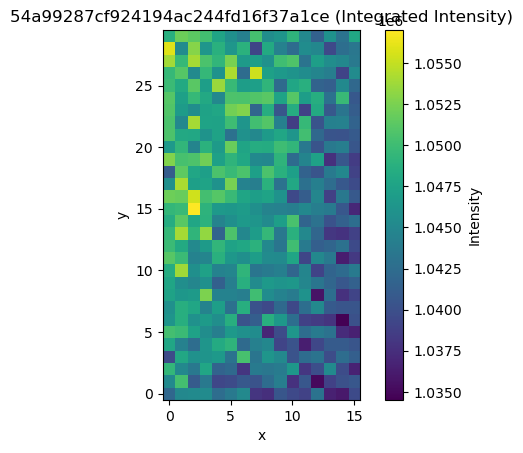

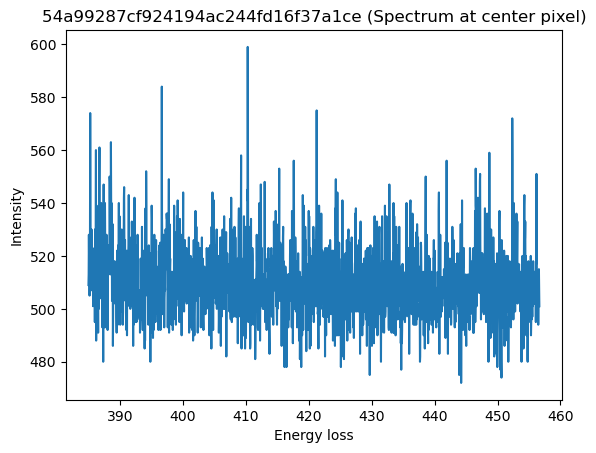

Showing: 54a99287cf924194ac244fd16f37a1ce
Shape: (30, 16, 2048)


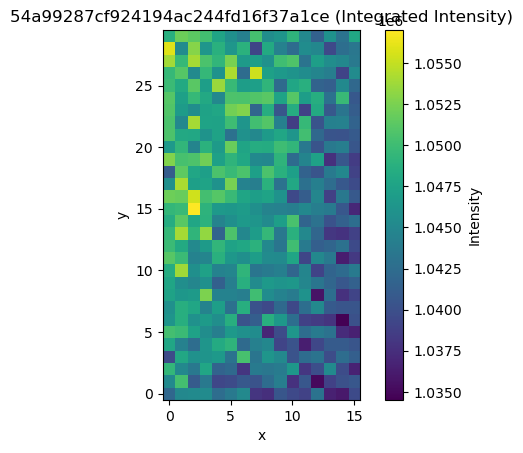

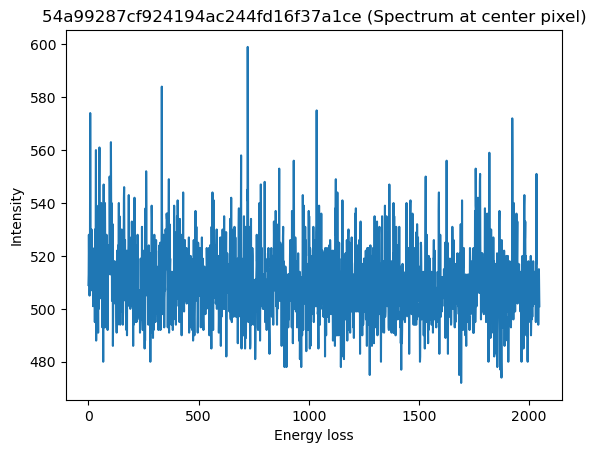

Cube reshaped from (30, 2048, 16) to (30, 16, 2048)
[482. 492. 499. 494. 516. 502. 500. 493. 509. 499. 466. 493. 492. 501.
 520. 502. 499. 502. 496. 502. 499. 502. 506. 502. 520. 499. 502. 517.
 503. 496.]
Showing: 5aadde5924dc4aa1a55698361d20526b
Shape: (30, 16, 2048)


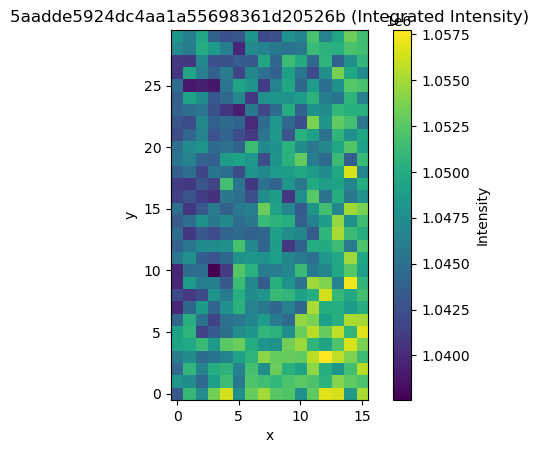

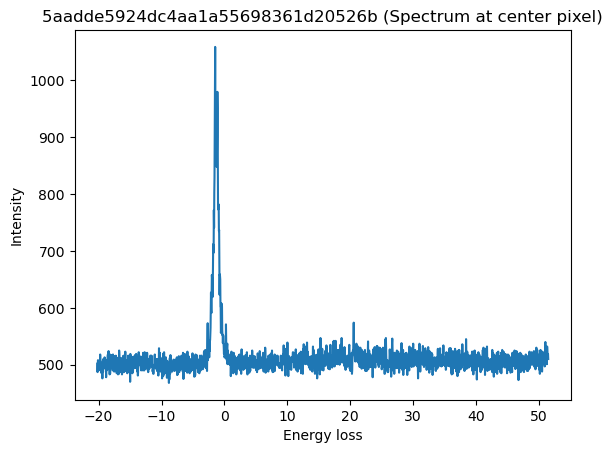

Showing: 5aadde5924dc4aa1a55698361d20526b
Shape: (30, 16, 2048)


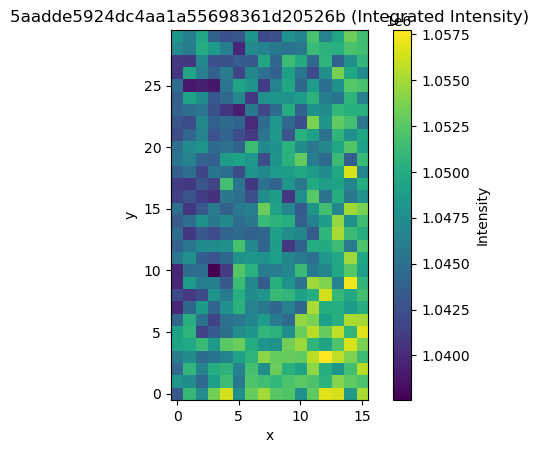

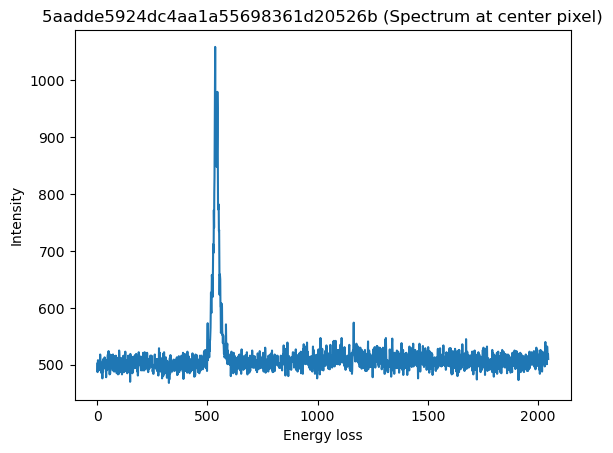

Cube reshaped from (30, 2048, 16) to (30, 16, 2048)
[1615. 1593. 1701. 1547. 1558. 1530. 1471. 1523. 1417. 1328. 1515. 1368.
 1494. 1450. 1384. 1420. 1508. 1324. 1654. 1729. 1544. 1337. 1534. 1415.
 1640. 1521. 1715. 1614. 1760. 1672.]
Showing: 8bac7e346b444a1aaf002611a0f16316
Shape: (30, 16, 2048)


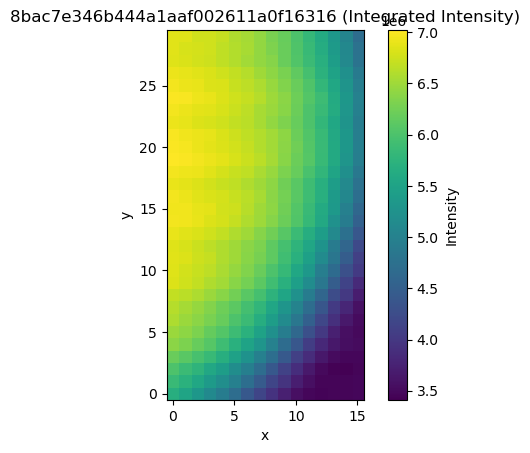

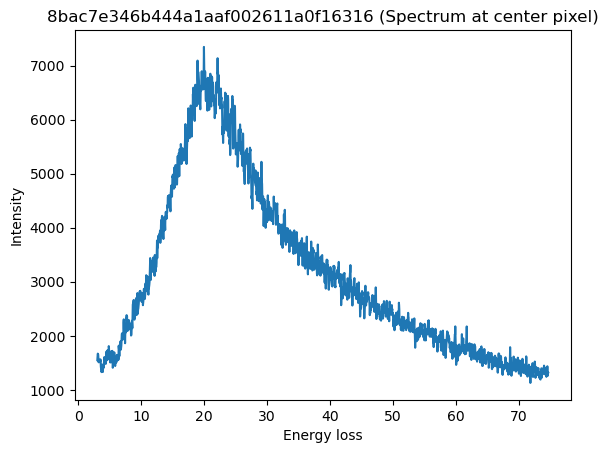

Showing: 8bac7e346b444a1aaf002611a0f16316
Shape: (30, 16, 2048)


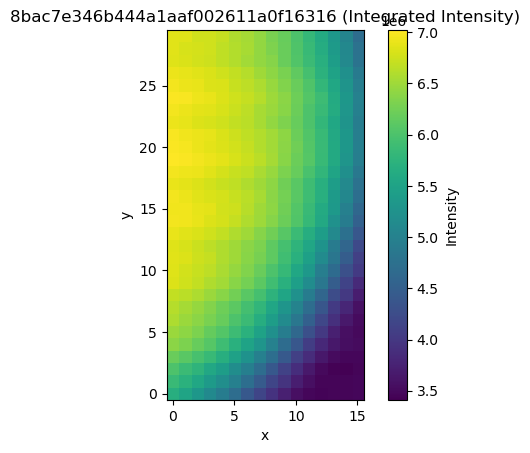

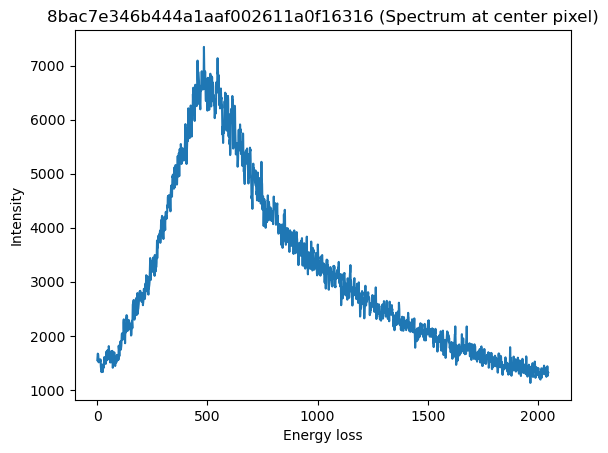

Cube reshaped from (30, 2048, 16) to (30, 16, 2048)
[500. 498. 508. 509. 495. 504. 493. 519. 495. 518. 496. 518. 508. 491.
 509. 498. 527. 507. 499. 501. 513. 491. 504. 494. 520. 510. 520. 493.
 524. 504.]
Showing: b408f69a1f084a519e542c486b42b273
Shape: (30, 16, 2048)


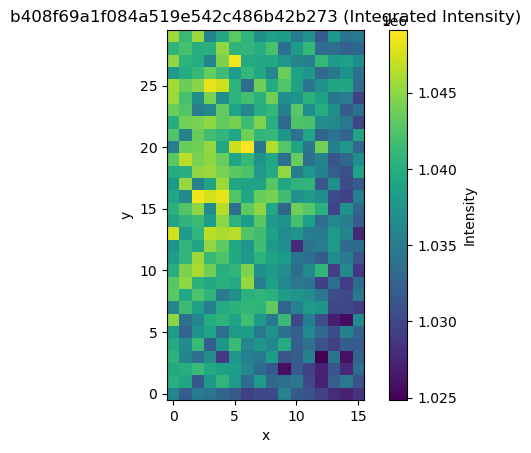

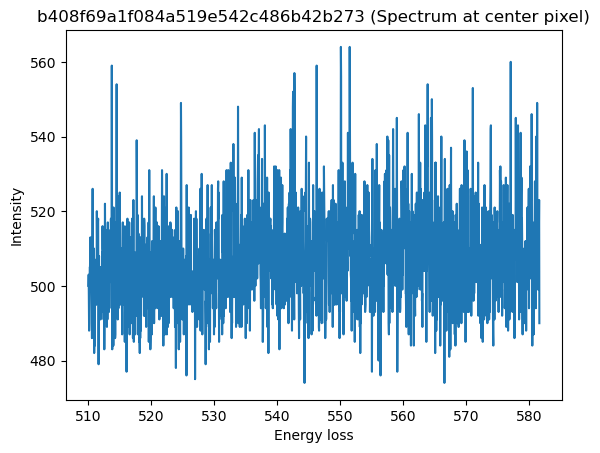

Showing: b408f69a1f084a519e542c486b42b273
Shape: (30, 16, 2048)


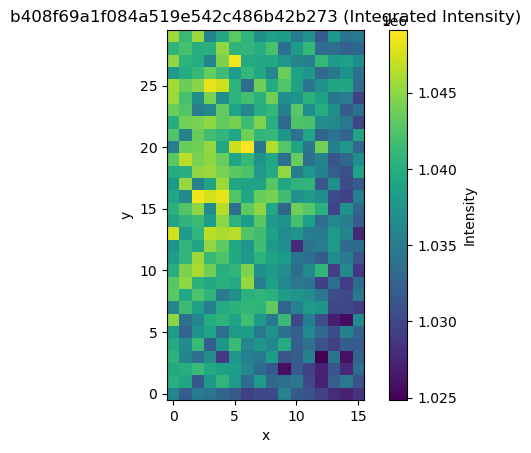

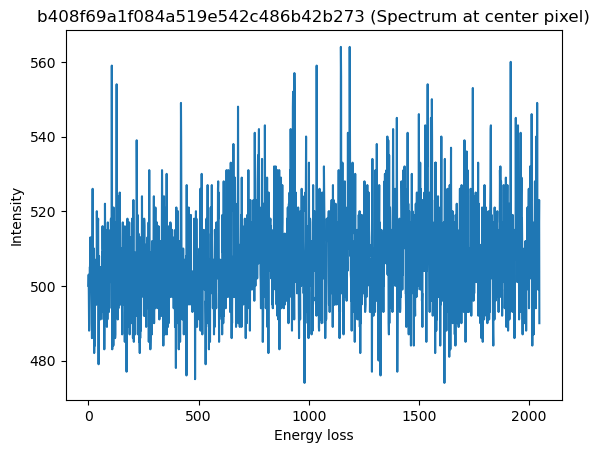

In [2]:
emd_path_folder = "Demo_EELS_Data/"
emd_file = "0008-20260215_1412_DF_6600_x-EELS-(RT, 0.2mol%HNO3).emd"
custom_file = "0008-20260215_1412_(RT, 0.2mol%HNO3)_"
emd_path = emd_path_folder + emd_file
import_file(emd_path)